STEP 1 — Project folders created
STEP 2 — Raw simulated data saved: catastrophe-exposure-analysis-python\data\raw\simulated_property_exposure_raw_15000_plus_quality_issues.csv
STEP 3 — Cleaned data saved: catastrophe-exposure-analysis-python\data\processed\cleaned_validated_property_exposure_15000.csv
STEP 4 — Validation completed
                    validation_check  result
   Total records after deduplication   15000
    Duplicate location IDs remaining       0
                    Missing postcode     120
      Missing or invalid coordinates     120
              Invalid occupancy type       0
                 Invalid hazard zone       0
Zero or negative total insured value       0
                Records marked valid   14760
              Records needing review     240
STEP 5 — Scored data saved: catastrophe-exposure-analysis-python\data\processed\scored_property_exposure_15000.csv
STEP 6 — Aggregation completed. Regional HHI: 0.1165
                                       metric    

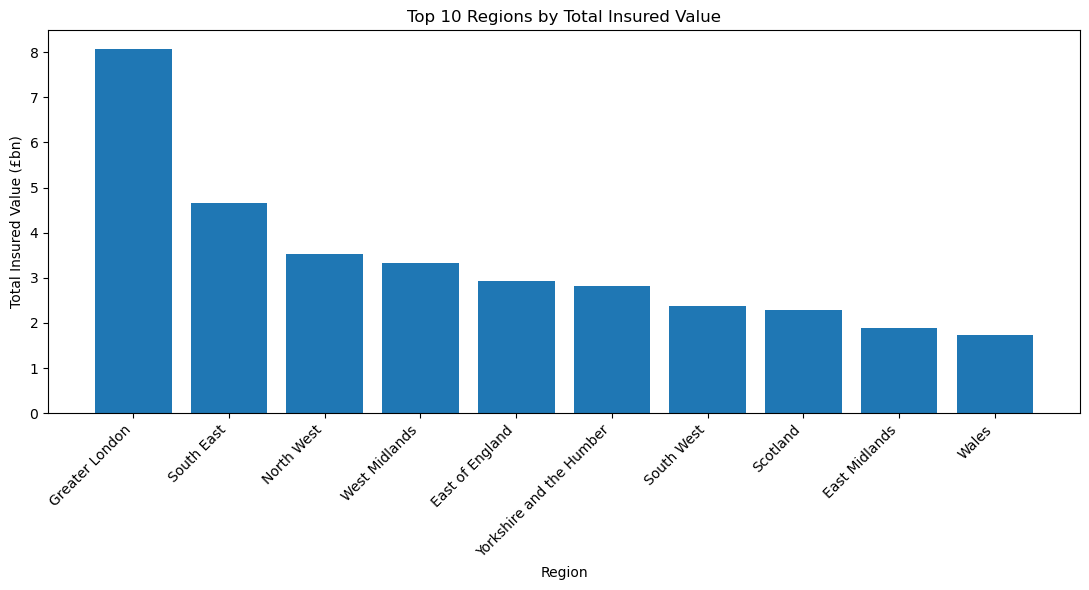

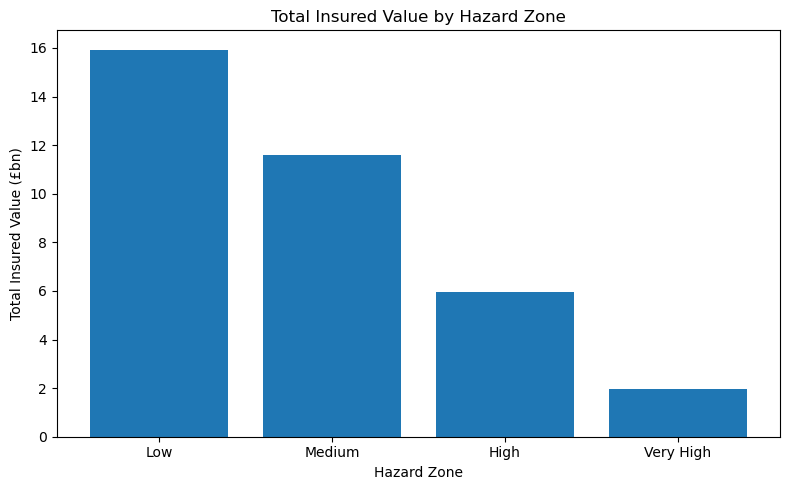

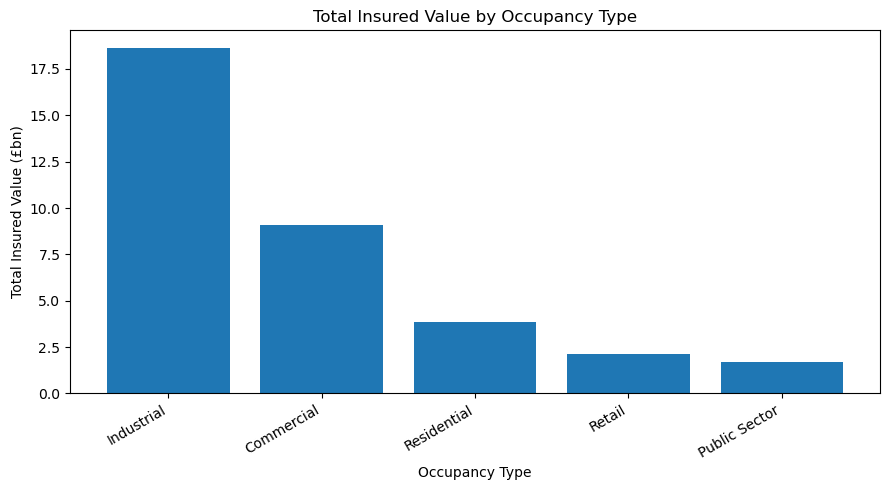

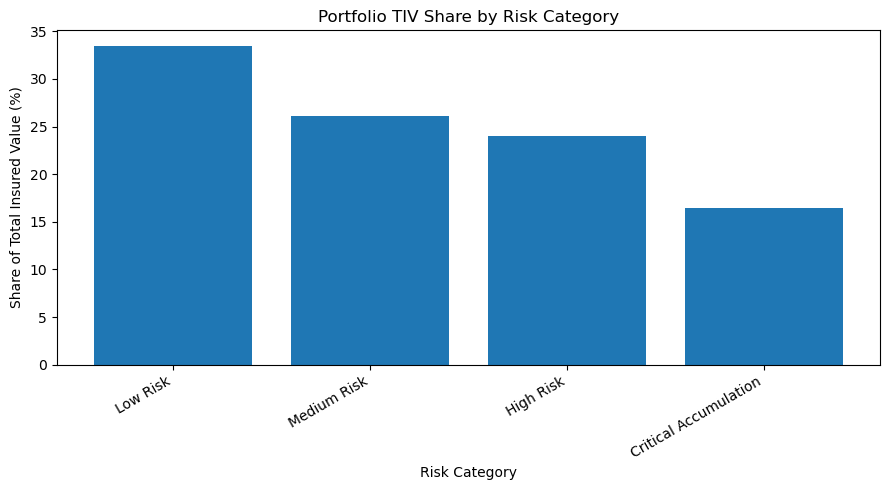

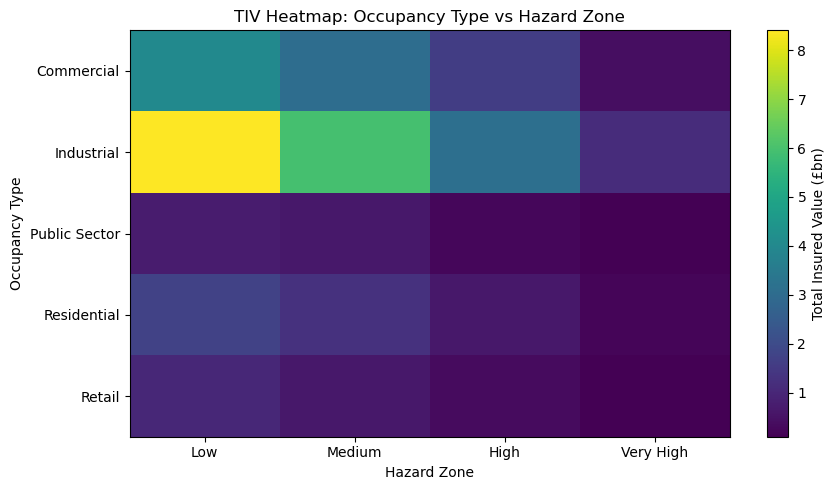

STEP 7 — Charts created
top_10_regions_by_tiv: catastrophe-exposure-analysis-python\outputs\charts\top_10_regions_by_tiv.png
tiv_by_hazard_zone: catastrophe-exposure-analysis-python\outputs\charts\tiv_by_hazard_zone.png
tiv_by_occupancy_type: catastrophe-exposure-analysis-python\outputs\charts\tiv_by_occupancy_type.png
portfolio_share_by_risk_category: catastrophe-exposure-analysis-python\outputs\charts\portfolio_share_by_risk_category.png
occupancy_hazard_tiv_heatmap: catastrophe-exposure-analysis-python\outputs\charts\occupancy_hazard_tiv_heatmap.png
folium is not installed, so the interactive map was skipped.
STEP 8 — Interactive map: not created
STEP 9 — Executive findings
1. The simulated portfolio contains 15,000 deduplicated property locations with total insured value of £35,397,743,868.
2. The largest regional accumulation is Greater London, with £8,078,021,737 of TIV across 3,362 locations.
3. The largest postcode-level accumulation is DY74 5KU in West Midlands, with £158,570,

In [4]:
from pathlib import Path
from datetime import datetime
import json
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1. Project setup

def create_project_folders(project_root: Path) -> dict:
    """Create a clean portfolio project folder structure."""
    folders = {
        "data_raw": project_root / "data" / "raw",
        "data_processed": project_root / "data" / "processed",
        "outputs_charts": project_root / "outputs" / "charts",
        "outputs_maps": project_root / "outputs" / "maps",
        "outputs_tables": project_root / "outputs" / "tables",
        "outputs_reports": project_root / "outputs" / "reports",
        "src": project_root / "src",
        "notebooks": project_root / "notebooks",
    }
    for folder in folders.values():
        folder.mkdir(parents=True, exist_ok=True)
    return folders


# 2. Simulated exposure data generation

def make_postcode(region: str, postcode_prefix_by_region: dict) -> str:
    """Generate a realistic-looking UK-style postcode."""
    prefix = np.random.choice(postcode_prefix_by_region[region])
    outward_num = np.random.randint(1, 99)
    inward_num = np.random.randint(1, 9)
    letters = "".join(np.random.choice(list("ABCDEFGHJKMNPRSTUVWXYZ"), size=2))
    return f"{prefix}{outward_num} {inward_num}{letters}"


def generate_simulated_exposure_data(n: int = 15_000, seed: int = 42) -> pd.DataFrame:
    """
    Generate 15,000 simulated UK-style property insurance exposure records.

    Why: Real property exposure data is usually confidential, so simulated data
    allows us to demonstrate the full analytics workflow safely.
    """
    np.random.seed(seed)

    regions = pd.DataFrame({
        "region": [
            "Greater London", "South East", "North West", "West Midlands",
            "Yorkshire and the Humber", "East of England", "South West",
            "Scotland", "Wales", "North East", "East Midlands", "Northern Ireland"
        ],
        "lat_center": [51.5072, 51.4545, 53.4808, 52.4862, 53.8008, 52.2405,
                       51.4545, 55.9533, 51.4816, 54.9783, 52.9548, 54.5973],
        "lon_center": [-0.1276, -0.9781, -2.2426, -1.8904, -1.5491, 0.7176,
                       -2.5879, -3.1883, -3.1791, -1.6178, -1.1581, -5.9301],
        "weight": [0.22, 0.13, 0.10, 0.09, 0.08, 0.08, 0.07, 0.07, 0.05, 0.03, 0.05, 0.03]
    })

    region_choices = np.random.choice(regions["region"], size=n, p=regions["weight"] / regions["weight"].sum())
    region_lookup = regions.set_index("region")

    latitudes, longitudes = [], []
    for region in region_choices:
        latitudes.append(np.random.normal(region_lookup.loc[region, "lat_center"], 0.28))
        longitudes.append(np.random.normal(region_lookup.loc[region, "lon_center"], 0.38))

    occupancy_types = ["Residential", "Commercial", "Industrial", "Retail", "Public Sector"]
    occupancy_probs = [0.60, 0.20, 0.10, 0.07, 0.03]
    occupancy = np.random.choice(occupancy_types, size=n, p=occupancy_probs)

    construction_types = ["Masonry", "Timber", "Steel Frame", "Reinforced Concrete", "Mixed"]
    construction = np.random.choice(construction_types, size=n, p=[0.45, 0.20, 0.14, 0.13, 0.08])

    building_value = np.zeros(n)
    contents_value = np.zeros(n)
    business_interruption_value = np.zeros(n)

    for i, occ in enumerate(occupancy):
        if occ == "Residential":
            building_value[i] = np.random.lognormal(np.log(320_000), 0.55)
            contents_value[i] = building_value[i] * np.random.uniform(0.08, 0.22)
            business_interruption_value[i] = 0
        elif occ == "Commercial":
            building_value[i] = np.random.lognormal(np.log(1_500_000), 0.75)
            contents_value[i] = building_value[i] * np.random.uniform(0.15, 0.45)
            business_interruption_value[i] = building_value[i] * np.random.uniform(0.10, 0.40)
        elif occ == "Industrial":
            building_value[i] = np.random.lognormal(np.log(4_500_000), 0.85)
            contents_value[i] = building_value[i] * np.random.uniform(0.20, 0.60)
            business_interruption_value[i] = building_value[i] * np.random.uniform(0.20, 0.70)
        elif occ == "Retail":
            building_value[i] = np.random.lognormal(np.log(900_000), 0.70)
            contents_value[i] = building_value[i] * np.random.uniform(0.25, 0.55)
            business_interruption_value[i] = building_value[i] * np.random.uniform(0.15, 0.50)
        else:
            building_value[i] = np.random.lognormal(np.log(2_000_000), 0.70)
            contents_value[i] = building_value[i] * np.random.uniform(0.10, 0.35)
            business_interruption_value[i] = building_value[i] * np.random.uniform(0.05, 0.20)

    building_value = np.clip(building_value, 50_000, 80_000_000)
    contents_value = np.clip(contents_value, 0, 30_000_000)
    business_interruption_value = np.clip(business_interruption_value, 0, 50_000_000)

    postcode_prefix_by_region = {
        "Greater London": ["E", "EC", "N", "NW", "SE", "SW", "W", "WC"],
        "South East": ["BN", "GU", "OX", "PO", "RG", "RH", "SO"],
        "North West": ["BB", "BL", "CH", "L", "M", "PR", "WA", "WN"],
        "West Midlands": ["B", "CV", "DY", "ST", "WS", "WV"],
        "Yorkshire and the Humber": ["BD", "DN", "HD", "HG", "HU", "LS", "S", "YO"],
        "East of England": ["AL", "CB", "CM", "CO", "IP", "LU", "NR"],
        "South West": ["BA", "BH", "BS", "EX", "GL", "PL", "TR"],
        "Scotland": ["AB", "DD", "EH", "G", "IV", "PA"],
        "Wales": ["CF", "LD", "LL", "NP", "SA", "SY"],
        "North East": ["DH", "DL", "NE", "SR", "TS"],
        "East Midlands": ["DE", "LE", "LN", "NG", "NN"],
        "Northern Ireland": ["BT"]
    }

    postcodes = [make_postcode(region, postcode_prefix_by_region) for region in region_choices]

    base_hazard_probs = {
        "Greater London": [0.38, 0.36, 0.20, 0.06],
        "South East": [0.42, 0.34, 0.18, 0.06],
        "North West": [0.46, 0.32, 0.17, 0.05],
        "West Midlands": [0.55, 0.30, 0.12, 0.03],
        "Yorkshire and the Humber": [0.48, 0.32, 0.16, 0.04],
        "East of England": [0.40, 0.35, 0.19, 0.06],
        "South West": [0.44, 0.33, 0.17, 0.06],
        "Scotland": [0.50, 0.31, 0.15, 0.04],
        "Wales": [0.47, 0.32, 0.16, 0.05],
        "North East": [0.52, 0.30, 0.14, 0.04],
        "East Midlands": [0.55, 0.30, 0.12, 0.03],
        "Northern Ireland": [0.50, 0.31, 0.15, 0.04]
    }
    hazard_labels = ["Low", "Medium", "High", "Very High"]
    hazard_zone = [np.random.choice(hazard_labels, p=base_hazard_probs[r]) for r in region_choices]

    df = pd.DataFrame({
        "policy_id": [f"POL{i:07d}" for i in range(1, n + 1)],
        "location_id": [f"LOC{i:07d}" for i in range(1, n + 1)],
        "postcode": postcodes,
        "latitude": np.array(latitudes),
        "longitude": np.array(longitudes),
        "region": region_choices,
        "country": "UK",
        "occupancy_type": occupancy,
        "construction_type": construction,
        "year_built": np.random.choice(np.arange(1900, 2024), size=n, replace=True),
        "building_value": building_value.round(2),
        "contents_value": contents_value.round(2),
        "business_interruption_value": business_interruption_value.round(2),
        "hazard_zone": hazard_zone,
    })
    df["total_insured_value"] = (
        df["building_value"] + df["contents_value"] + df["business_interruption_value"]
    ).round(2)
    return df


def add_realistic_data_quality_issues(df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    """Add common insurance exposure data quality issues deliberately."""
    np.random.seed(seed)
    issue_df = df.copy()
    n = len(issue_df)

    idx = np.random.choice(issue_df.index, size=int(0.008 * n), replace=False)
    issue_df.loc[idx, "postcode"] = np.nan

    idx = np.random.choice(issue_df.index, size=int(0.012 * n), replace=False)
    issue_df.loc[idx, "occupancy_type"] = np.random.choice(
        ["res", "commercial property", "factory", "shop", "PUBLIC"], size=len(idx)
    )

    idx = np.random.choice(issue_df.index, size=int(0.005 * n), replace=False)
    issue_df.loc[idx, ["latitude", "longitude"]] = np.nan

    idx = np.random.choice(issue_df.index, size=int(0.003 * n), replace=False)
    issue_df.loc[idx, "latitude"] = np.random.choice([95, -95], size=len(idx))
    issue_df.loc[idx, "longitude"] = np.random.choice([200, -200], size=len(idx))

    idx = np.random.choice(issue_df.index, size=int(0.0025 * n), replace=False)
    issue_df.loc[idx, "building_value"] = -abs(issue_df.loc[idx, "building_value"])

    duplicate_rows = issue_df.sample(35, random_state=seed).copy()
    issue_df = pd.concat([issue_df, duplicate_rows], ignore_index=True)
    return issue_df


# 3. Cleaning, validation, risk scoring

def clean_exposure_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean postcodes, categories, coordinates, values, and duplicates."""
    clean_df = df.copy()

    clean_df["postcode"] = (
        clean_df["postcode"].astype("string").str.upper().str.replace(r"\s+", " ", regex=True).str.strip()
    )
    clean_df.loc[clean_df["postcode"].isin(["<NA>", "NAN", "NONE", ""]), "postcode"] = pd.NA

    occupancy_map = {
        "res": "Residential", "residential": "Residential", "residential property": "Residential",
        "commercial property": "Commercial", "commercial": "Commercial",
        "factory": "Industrial", "industrial": "Industrial",
        "shop": "Retail", "retail": "Retail",
        "public": "Public Sector", "public sector": "Public Sector"
    }
    clean_df["occupancy_type"] = clean_df["occupancy_type"].astype("string").str.lower().str.strip().replace(occupancy_map)
    clean_df["hazard_zone"] = clean_df["hazard_zone"].astype("string").str.title().str.strip()

    value_cols = ["building_value", "contents_value", "business_interruption_value"]
    for col in value_cols:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce").fillna(0)
        clean_df.loc[clean_df[col] < 0, col] = 0

    clean_df["latitude"] = pd.to_numeric(clean_df["latitude"], errors="coerce")
    clean_df["longitude"] = pd.to_numeric(clean_df["longitude"], errors="coerce")

    valid_lat = clean_df["latitude"].between(49.5, 61.0)
    valid_lon = clean_df["longitude"].between(-8.8, 2.1)
    clean_df.loc[~(valid_lat & valid_lon), ["latitude", "longitude"]] = np.nan

    clean_df["total_insured_value"] = clean_df[value_cols].sum(axis=1).round(2)
    clean_df = clean_df.drop_duplicates(subset=["location_id"], keep="first").copy()
    return clean_df


def validate_exposure_data(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Create validation flags and a validation summary table."""
    out = df.copy()
    approved_occupancies = ["Residential", "Commercial", "Industrial", "Retail", "Public Sector"]
    approved_hazard_zones = ["Low", "Medium", "High", "Very High"]

    out["is_valid_postcode"] = out["postcode"].notna()
    out["is_valid_geocode"] = out[["latitude", "longitude"]].notna().all(axis=1)
    out["is_valid_occupancy"] = out["occupancy_type"].isin(approved_occupancies)
    out["is_valid_hazard_zone"] = out["hazard_zone"].isin(approved_hazard_zones)
    out["is_positive_tiv"] = out["total_insured_value"] > 0

    flags = ["is_valid_postcode", "is_valid_geocode", "is_valid_occupancy", "is_valid_hazard_zone", "is_positive_tiv"]
    out["record_quality_status"] = np.where(out[flags].all(axis=1), "Valid", "Needs Review")

    summary = pd.DataFrame({
        "validation_check": [
            "Total records after deduplication", "Duplicate location IDs remaining", "Missing postcode",
            "Missing or invalid coordinates", "Invalid occupancy type", "Invalid hazard zone",
            "Zero or negative total insured value", "Records marked valid", "Records needing review"
        ],
        "result": [
            len(out), int(out["location_id"].duplicated().sum()), int((~out["is_valid_postcode"]).sum()),
            int((~out["is_valid_geocode"]).sum()), int((~out["is_valid_occupancy"]).sum()),
            int((~out["is_valid_hazard_zone"]).sum()), int((~out["is_positive_tiv"]).sum()),
            int((out["record_quality_status"] == "Valid").sum()),
            int((out["record_quality_status"] == "Needs Review").sum())
        ]
    })
    return out, summary


def add_risk_score(df: pd.DataFrame) -> pd.DataFrame:
    """Create a simple hazard/occupancy/value-based risk score."""
    out = df.copy()
    hazard_weight = {"Low": 1, "Medium": 2, "High": 3, "Very High": 4}
    occupancy_weight = {"Residential": 1.0, "Commercial": 1.2, "Retail": 1.3, "Industrial": 1.5, "Public Sector": 1.1}

    out["hazard_weight"] = out["hazard_zone"].map(hazard_weight)
    out["occupancy_weight"] = out["occupancy_type"].map(occupancy_weight)
    out["risk_score"] = (
        out["hazard_weight"].fillna(0) * out["occupancy_weight"].fillna(0) * np.log1p(out["total_insured_value"])
    ).round(3)

    valid_scores = out.loc[out["risk_score"] > 0, "risk_score"]
    q50, q80, q95 = valid_scores.quantile([0.50, 0.80, 0.95])

    def classify(score):
        if score <= 0 or pd.isna(score):
            return "Unclassified"
        if score <= q50:
            return "Low Risk"
        if score <= q80:
            return "Medium Risk"
        if score <= q95:
            return "High Risk"
        return "Critical Accumulation"

    out["risk_category"] = out["risk_score"].apply(classify)
    return out


# 4. Aggregation and concentration analysis

def create_aggregation_outputs(df: pd.DataFrame) -> dict:
    """Create all summary tables needed for catastrophe exposure analysis."""
    total_tiv = df["total_insured_value"].sum()
    high_vhigh_share = df.loc[df["hazard_zone"].isin(["High", "Very High"]), "total_insured_value"].sum() / total_tiv
    top_5_region_share = df.groupby("region")["total_insured_value"].sum().sort_values(ascending=False).head(5).sum() / total_tiv

    portfolio_summary = pd.DataFrame({
        "metric": [
            "Number of records", "Number of valid records", "Number of unique regions", "Number of unique postcodes",
            "Total insured value", "Average TIV", "Median TIV", "Maximum TIV",
            "Share of TIV in High + Very High hazard zones", "Share of TIV in top 5 regions"
        ],
        "value": [
            f"{len(df):,}", f"{(df['record_quality_status'] == 'Valid').sum():,}", f"{df['region'].nunique():,}",
            f"{df['postcode'].nunique():,}", f"£{total_tiv:,.0f}", f"£{df['total_insured_value'].mean():,.0f}",
            f"£{df['total_insured_value'].median():,.0f}", f"£{df['total_insured_value'].max():,.0f}",
            f"{high_vhigh_share:.1%}", f"{top_5_region_share:.1%}"
        ]
    })

    region_exposure = df.groupby("region").agg(
        location_count=("location_id", "count"),
        valid_location_count=("record_quality_status", lambda s: (s == "Valid").sum()),
        total_tiv=("total_insured_value", "sum"),
        avg_tiv=("total_insured_value", "mean"),
        max_tiv=("total_insured_value", "max"),
        avg_risk_score=("risk_score", "mean")
    ).sort_values("total_tiv", ascending=False).reset_index()

    hazard_exposure = df.groupby("hazard_zone", dropna=False).agg(
        location_count=("location_id", "count"), total_tiv=("total_insured_value", "sum"),
        avg_tiv=("total_insured_value", "mean"), avg_risk_score=("risk_score", "mean")
    ).reset_index()
    hazard_exposure["tiv_share"] = hazard_exposure["total_tiv"] / hazard_exposure["total_tiv"].sum()

    occupancy_exposure = df.groupby("occupancy_type", dropna=False).agg(
        location_count=("location_id", "count"), total_tiv=("total_insured_value", "sum"),
        avg_tiv=("total_insured_value", "mean"), avg_risk_score=("risk_score", "mean")
    ).sort_values("total_tiv", ascending=False).reset_index()

    risk_category_exposure = df.groupby("risk_category", dropna=False).agg(
        location_count=("location_id", "count"), total_tiv=("total_insured_value", "sum"),
        avg_tiv=("total_insured_value", "mean"), avg_risk_score=("risk_score", "mean")
    ).sort_values("total_tiv", ascending=False).reset_index()
    risk_category_exposure["tiv_share"] = risk_category_exposure["total_tiv"] / risk_category_exposure["total_tiv"].sum()

    postcode_exposure = df.groupby(["postcode", "region"], dropna=False).agg(
        location_count=("location_id", "count"), total_tiv=("total_insured_value", "sum"), avg_risk_score=("risk_score", "mean")
    ).sort_values("total_tiv", ascending=False).reset_index()

    occupancy_hazard_matrix = df.pivot_table(
        index="occupancy_type", columns="hazard_zone", values="total_insured_value", aggfunc="sum", fill_value=0
    ).reset_index()

    region_shares = df.groupby("region")["total_insured_value"].sum() / total_tiv
    hhi_region = float((region_shares ** 2).sum())

    return {
        "portfolio_summary": portfolio_summary,
        "region_exposure": region_exposure,
        "hazard_exposure": hazard_exposure,
        "occupancy_exposure": occupancy_exposure,
        "risk_category_exposure": risk_category_exposure,
        "postcode_exposure": postcode_exposure,
        "occupancy_hazard_matrix": occupancy_hazard_matrix,
        "hhi_region": hhi_region,
        "high_vhigh_share": high_vhigh_share,
        "top_5_region_share": top_5_region_share,
    }


# 5. Visualisation outputs

def create_static_charts(df: pd.DataFrame, aggs: dict, charts_dir: Path) -> dict:
    """Create portfolio concentration charts."""
    paths = {}

    top_regions = aggs["region_exposure"].head(10)
    plt.figure(figsize=(11, 6))
    plt.bar(top_regions["region"], top_regions["total_tiv"] / 1e9)
    plt.xticks(rotation=45, ha="right")
    plt.title("Top 10 Regions by Total Insured Value")
    plt.ylabel("Total Insured Value (£bn)")
    plt.xlabel("Region")
    plt.tight_layout()
    paths["top_10_regions_by_tiv"] = charts_dir / "top_10_regions_by_tiv.png"
    plt.savefig(paths["top_10_regions_by_tiv"], dpi=160)
    plt.show()

    hazard_order = ["Low", "Medium", "High", "Very High"]
    hazard_plot = aggs["hazard_exposure"].set_index("hazard_zone").reindex(hazard_order).reset_index()
    plt.figure(figsize=(8, 5))
    plt.bar(hazard_plot["hazard_zone"], hazard_plot["total_tiv"] / 1e9)
    plt.title("Total Insured Value by Hazard Zone")
    plt.ylabel("Total Insured Value (£bn)")
    plt.xlabel("Hazard Zone")
    plt.tight_layout()
    paths["tiv_by_hazard_zone"] = charts_dir / "tiv_by_hazard_zone.png"
    plt.savefig(paths["tiv_by_hazard_zone"], dpi=160)
    plt.show()

    occ = aggs["occupancy_exposure"]
    plt.figure(figsize=(9, 5))
    plt.bar(occ["occupancy_type"].astype(str), occ["total_tiv"] / 1e9)
    plt.title("Total Insured Value by Occupancy Type")
    plt.ylabel("Total Insured Value (£bn)")
    plt.xlabel("Occupancy Type")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    paths["tiv_by_occupancy_type"] = charts_dir / "tiv_by_occupancy_type.png"
    plt.savefig(paths["tiv_by_occupancy_type"], dpi=160)
    plt.show()

    risk = aggs["risk_category_exposure"]
    plt.figure(figsize=(9, 5))
    plt.bar(risk["risk_category"].astype(str), risk["tiv_share"] * 100)
    plt.title("Portfolio TIV Share by Risk Category")
    plt.ylabel("Share of Total Insured Value (%)")
    plt.xlabel("Risk Category")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    paths["portfolio_share_by_risk_category"] = charts_dir / "portfolio_share_by_risk_category.png"
    plt.savefig(paths["portfolio_share_by_risk_category"], dpi=160)
    plt.show()

    matrix = df.pivot_table(index="occupancy_type", columns="hazard_zone", values="total_insured_value", aggfunc="sum", fill_value=0).reindex(columns=hazard_order)
    plt.figure(figsize=(9, 5))
    plt.imshow(matrix.values / 1e9, aspect="auto")
    plt.xticks(range(len(matrix.columns)), matrix.columns)
    plt.yticks(range(len(matrix.index)), matrix.index)
    plt.title("TIV Heatmap: Occupancy Type vs Hazard Zone")
    plt.xlabel("Hazard Zone")
    plt.ylabel("Occupancy Type")
    cbar = plt.colorbar()
    cbar.set_label("Total Insured Value (£bn)")
    plt.tight_layout()
    paths["occupancy_hazard_tiv_heatmap"] = charts_dir / "occupancy_hazard_tiv_heatmap.png"
    plt.savefig(paths["occupancy_hazard_tiv_heatmap"], dpi=160)
    plt.show()

    return paths


def create_interactive_map(df: pd.DataFrame, maps_dir: Path) -> Path | None:
    """Create an interactive HTML map using folium."""
    try:
        import folium
        from folium.plugins import MarkerCluster
    except ImportError:
        print("folium is not installed, so the interactive map was skipped.")
        return None

    valid_geo = df[df["is_valid_geocode"]].copy()
    if valid_geo.empty:
        print("No valid geocoded records found, so the map was skipped.")
        return None

    sample = valid_geo.sample(min(2500, len(valid_geo)), random_state=42)
    centre = [valid_geo["latitude"].mean(), valid_geo["longitude"].mean()]
    m = folium.Map(location=centre, zoom_start=6)
    cluster = MarkerCluster().add_to(m)

    for _, row in sample.iterrows():
        popup = (
            f"<b>Location:</b> {row['location_id']}<br>"
            f"<b>Postcode:</b> {row['postcode']}<br>"
            f"<b>Region:</b> {row['region']}<br>"
            f"<b>Occupancy:</b> {row['occupancy_type']}<br>"
            f"<b>Hazard:</b> {row['hazard_zone']}<br>"
            f"<b>Risk Category:</b> {row['risk_category']}<br>"
            f"<b>TIV:</b> £{row['total_insured_value']:,.0f}"
        )
        folium.CircleMarker(location=[row["latitude"], row["longitude"]], radius=3, popup=popup, fill=True).add_to(cluster)

    map_path = maps_dir / "interactive_portfolio_concentration_map.html"
    m.save(map_path)
    return map_path


# 6. Reports and documentation

def create_executive_findings(df: pd.DataFrame, aggs: dict) -> list[str]:
    """Translate outputs into business-readable findings."""
    top_region = aggs["region_exposure"].iloc[0]
    top_postcode = aggs["postcode_exposure"].iloc[0]
    highest_occupancy = aggs["occupancy_exposure"].iloc[0]
    critical = aggs["risk_category_exposure"].loc[aggs["risk_category_exposure"]["risk_category"] == "Critical Accumulation", "tiv_share"]
    critical_share = float(critical.iloc[0]) if len(critical) else 0.0

    return [
        f"The simulated portfolio contains {len(df):,} deduplicated property locations with total insured value of £{df['total_insured_value'].sum():,.0f}.",
        f"The largest regional accumulation is {top_region['region']}, with £{top_region['total_tiv']:,.0f} of TIV across {int(top_region['location_count']):,} locations.",
        f"The largest postcode-level accumulation is {top_postcode['postcode']} in {top_postcode['region']}, with £{top_postcode['total_tiv']:,.0f} of TIV.",
        f"{aggs['high_vhigh_share']:.1%} of portfolio TIV sits in High or Very High hazard zones.",
        f"The highest TIV occupancy segment is {highest_occupancy['occupancy_type']}, contributing £{highest_occupancy['total_tiv']:,.0f}.",
        f"The regional HHI concentration index is {aggs['hhi_region']:.4f}; this gives a simple quantitative read on geographic concentration.",
        f"Critical Accumulation locations account for {critical_share:.1%} of portfolio TIV."
    ]


def save_tables(aggs: dict, validation_summary: pd.DataFrame, tables_dir: Path) -> None:
    """Save all CSV output tables."""
    validation_summary.to_csv(tables_dir / "validation_summary.csv", index=False)
    aggs["portfolio_summary"].to_csv(tables_dir / "portfolio_summary.csv", index=False)
    aggs["region_exposure"].to_csv(tables_dir / "region_exposure_summary.csv", index=False)
    aggs["hazard_exposure"].to_csv(tables_dir / "hazard_exposure_summary.csv", index=False)
    aggs["occupancy_exposure"].to_csv(tables_dir / "occupancy_exposure_summary.csv", index=False)
    aggs["risk_category_exposure"].to_csv(tables_dir / "risk_category_exposure_summary.csv", index=False)
    aggs["postcode_exposure"].to_csv(tables_dir / "postcode_exposure_summary.csv", index=False)
    aggs["occupancy_hazard_matrix"].to_csv(tables_dir / "occupancy_hazard_tiv_matrix.csv", index=False)


def write_readme(project_root: Path, df: pd.DataFrame, aggs: dict) -> None:
    """Create a polished GitHub README."""
    top_region = aggs["region_exposure"].iloc[0]
    readme = f"""# Catastrophe Exposure Analysis in Python
## Key Results

- Total insured value: **£{df['total_insured_value'].sum():,.0f}**
- Largest regional accumulation: **{top_region['region']}**
- Share of TIV in High and Very High hazard zones: **{aggs['high_vhigh_share']:.1%}**
- Regional HHI concentration index: **{aggs['hhi_region']:.4f}**


This project uses simulated data only. It is designed for portfolio demonstration and learning.
"""
    (project_root / "README.md").write_text(readme, encoding="utf-8")


def write_executive_report(reports_dir: Path, portfolio_summary: pd.DataFrame, findings: list[str]) -> None:
    """Write an executive report in Markdown."""
    try:
        summary_table = portfolio_summary.to_markdown(index=False)
    except Exception:
        summary_table = portfolio_summary.to_string(index=False)

    findings_text = "\n".join([f"{i}. {finding}" for i, finding in enumerate(findings, 1)])
    report = f"""# Executive Report: Catastrophe Exposure Analysis

Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M')}


## Limitations

This project uses simulated exposure and hazard data. It is suitable for demonstrating analytical workflow, but not for real underwriting decisions.
"""
    (reports_dir / "executive_report.md").write_text(report, encoding="utf-8")


def write_supporting_files(project_root: Path) -> None:
    """Write requirements, .gitignore, and LICENSE."""
    (project_root / "requirements.txt").write_text("pandas\nnumpy\nmatplotlib\nfolium\n", encoding="utf-8")
    (project_root / ".gitignore").write_text("__pycache__/\n*.pyc\n.ipynb_checkpoints/\nvenv/\n.env/\n.venv/\n.DS_Store\nThumbs.db\n*.zip\n", encoding="utf-8")
    (project_root / "LICENSE").write_text("MIT License\n\nCopyright (c) 2026 Your Name\n", encoding="utf-8")


def write_src_modules(src_dir: Path) -> None:
    """Write small reusable modules for GitHub project structure."""
    (src_dir / "cleaning.py").write_text("""import pandas as pd\nimport numpy as np\n\ndef clean_exposure_data(df):\n    df = df.copy()\n    value_cols = ['building_value', 'contents_value', 'business_interruption_value']\n    for col in value_cols:\n        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)\n        df.loc[df[col] < 0, col] = 0\n    df['total_insured_value'] = df[value_cols].sum(axis=1).round(2)\n    return df.drop_duplicates(subset=['location_id'], keep='first')\n""", encoding="utf-8")
    (src_dir / "risk_scoring.py").write_text("""import numpy as np\n\ndef add_risk_score(df):\n    df = df.copy()\n    hazard_weight = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}\n    occupancy_weight = {'Residential': 1.0, 'Commercial': 1.2, 'Retail': 1.3, 'Industrial': 1.5, 'Public Sector': 1.1}\n    df['risk_score'] = df['hazard_zone'].map(hazard_weight).fillna(0) * df['occupancy_type'].map(occupancy_weight).fillna(0) * np.log1p(df['total_insured_value'])\n    return df\n""", encoding="utf-8")
    (src_dir / "aggregation.py").write_text("""def aggregate_by_region(df):\n    return df.groupby('region').agg(location_count=('location_id', 'count'), total_tiv=('total_insured_value', 'sum')).sort_values('total_tiv', ascending=False).reset_index()\n""", encoding="utf-8")


def write_notebook(notebooks_dir: Path) -> None:
    """Create a simple notebook skeleton."""
    nb = {
        "cells": [
            {"cell_type": "markdown", "metadata": {}, "source": ["# Catastrophe Exposure Analysis\n", "Portfolio walkthrough notebook."]},
            {"cell_type": "code", "execution_count": None, "metadata": {}, "outputs": [], "source": ["import pandas as pd\n", "df = pd.read_csv('../data/processed/scored_property_exposure_15000.csv')\n", "df.head()"]}
        ],
        "metadata": {"kernelspec": {"display_name": "Python 3", "language": "python", "name": "python3"}, "language_info": {"name": "python"}},
        "nbformat": 4,
        "nbformat_minor": 5
    }
    (notebooks_dir / "catastrophe_exposure_analysis.ipynb").write_text(json.dumps(nb, indent=2), encoding="utf-8")


def zip_project(project_root: Path) -> Path:
    """Zip the full project folder."""
    zip_path = project_root.parent / f"{project_root.name}.zip"
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
        for file in project_root.rglob("*"):
            z.write(file, file.relative_to(project_root.parent))
    return zip_path

# 7. Main pipeline

def main() -> None:
    project_root = Path("catastrophe-exposure-analysis-python")
    folders = create_project_folders(project_root)

    print("STEP 1 — Project folders created")

    base_df = generate_simulated_exposure_data(n=15_000, seed=42)
    raw_df = add_realistic_data_quality_issues(base_df, seed=42)
    raw_path = folders["data_raw"] / "simulated_property_exposure_raw_15000_plus_quality_issues.csv"
    raw_df.to_csv(raw_path, index=False)
    print(f"STEP 2 — Raw simulated data saved: {raw_path}")

    cleaned_df = clean_exposure_data(raw_df)
    cleaned_path = folders["data_processed"] / "cleaned_validated_property_exposure_15000.csv"
    cleaned_df.to_csv(cleaned_path, index=False)
    print(f"STEP 3 — Cleaned data saved: {cleaned_path}")

    validated_df, validation_summary = validate_exposure_data(cleaned_df)
    print("STEP 4 — Validation completed")
    print(validation_summary.to_string(index=False))

    scored_df = add_risk_score(validated_df)
    scored_path = folders["data_processed"] / "scored_property_exposure_15000.csv"
    scored_df.to_csv(scored_path, index=False)
    print(f"STEP 5 — Scored data saved: {scored_path}")

    aggs = create_aggregation_outputs(scored_df)
    save_tables(aggs, validation_summary, folders["outputs_tables"])
    print(f"STEP 6 — Aggregation completed. Regional HHI: {aggs['hhi_region']:.4f}")
    print(aggs["portfolio_summary"].to_string(index=False))

    chart_paths = create_static_charts(scored_df, aggs, folders["outputs_charts"])
    print("STEP 7 — Charts created")
    for name, path in chart_paths.items():
        print(f"{name}: {path}")

    map_path = create_interactive_map(scored_df, folders["outputs_maps"])
    print(f"STEP 8 — Interactive map: {map_path if map_path else 'not created'}")

    findings = create_executive_findings(scored_df, aggs)
    print("STEP 9 — Executive findings")
    for i, finding in enumerate(findings, 1):
        print(f"{i}. {finding}")

    write_supporting_files(project_root)
    write_src_modules(folders["src"])
    write_notebook(folders["notebooks"])
    write_readme(project_root, scored_df, aggs)
    write_executive_report(folders["outputs_reports"], aggs["portfolio_summary"], findings)
    print("STEP 10 — README, report, notebook, and helper files created")

    zip_path = zip_project(project_root)
    print(f"STEP 11 — Project zip created: {zip_path}")
    print("Done. Your complete catastrophe exposure analysis project is ready for GitHub.")


if __name__ == "__main__":
    main()